In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_score, recall_score, roc_curve, auc
from sklearn.preprocessing import OrdinalEncoder
from sklearn.naive_bayes import CategoricalNB

u = "https://archive.ics.uci.edu/static/public/94/data.csv"
df = pd.read_csv(u)
X = df.drop(columns=["Class"])
y = np.ravel(df["Class"])
xtr, xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=1)

def r(m, tag):
    m.fit(xtr, ytr)
    for nm, x, yy in [("train", xtr, ytr), ("test", xte, yte)]:
        p = m.predict(x)
        z = m.predict_proba(x)[:, 1]
        print(tag, nm, 1 - accuracy_score(yy, p), accuracy_score(yy, p), f1_score(yy, p), roc_auc_score(yy, z))


In [2]:
r(DecisionTreeClassifier(criterion="entropy", random_state=1), "dt_ent")
r(DecisionTreeClassifier(criterion="gini", random_state=1), "dt_gini")


dt_ent train 0.00028985507246381825 0.9997101449275362 0.9996330275229358 0.9999998242271885
dt_ent test 0.07124239791485665 0.9287576020851434 0.9106753812636166 0.9287811063559994
dt_gini train 0.00028985507246381825 0.9997101449275362 0.9996330275229358 0.9999998242271885
dt_gini test 0.0955690703735882 0.9044309296264118 0.8764044943820225 0.8976699952448882


best_depth 20 min_test_err 0.06516072980017373


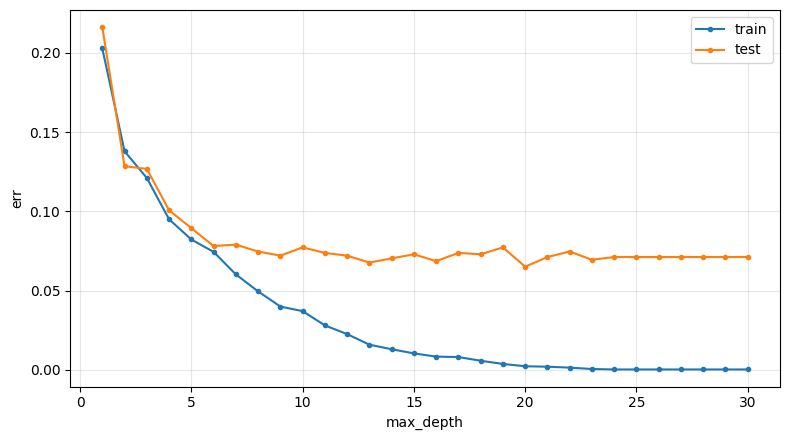

In [3]:
ds = range(1, 31)
etr, eva = [], []
for d in ds:
    t = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=1)
    t.fit(xtr, ytr)
    etr.append(1 - accuracy_score(ytr, t.predict(xtr)))
    eva.append(1 - accuracy_score(yte, t.predict(xte)))
bd = int(np.argmin(eva)) + 1
print("best_depth", bd, "min_test_err", min(eva))
plt.figure(figsize=(8, 4.5))
plt.plot(ds, etr, "o-", ms=3)
plt.plot(ds, eva, "o-", ms=3)
plt.xlabel("max_depth")
plt.ylabel("err")
plt.legend(["train", "test"])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


rf10 train 0.0028985507246376274 0.9971014492753624 0.9963289280469897 0.9999530686593212
rf10 test 0.052128583840138965 0.947871416159861 0.9321266968325792 0.982669202726264
rf50 train 0.00028985507246381825 0.9997101449275362 0.9996332966629996 0.9999991211359424
rf50 test 0.03388357949609033 0.9661164205039097 0.9560315670800451 0.9888096370264701
rf100 train 0.00028985507246381825 0.9997101449275362 0.9996332966629996 0.9999987695903194
rf100 test 0.03301476976542139 0.9669852302345786 0.9574944071588367 0.9892597876050087
rf500 train 0.00028985507246381825 0.9997101449275362 0.9996332966629996 0.9999998242271885
rf500 test 0.034752389226759384 0.9652476107732406 0.954954954954955 0.9887731811697575


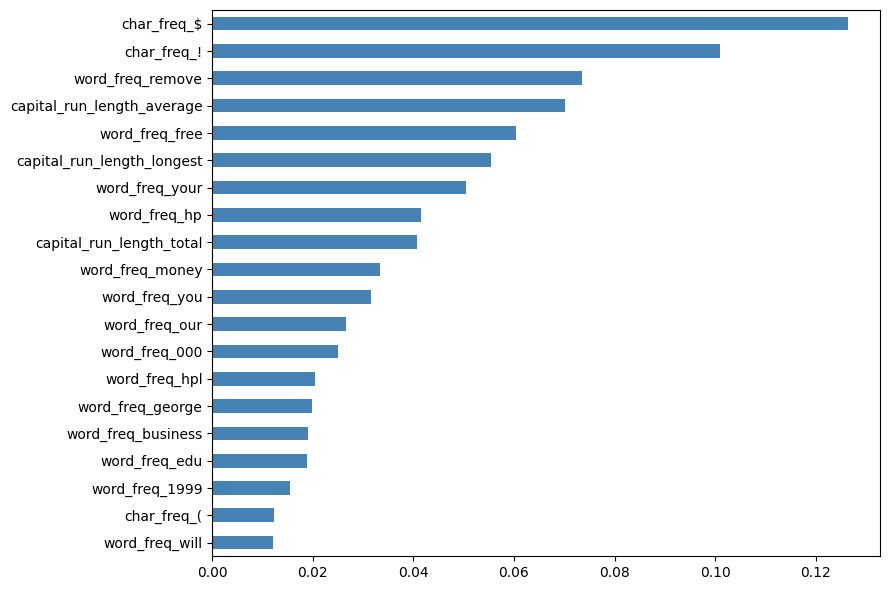

char_freq_$                   0.126489
char_freq_!                   0.100996
word_freq_remove              0.073543
capital_run_length_average    0.070250
word_freq_free                0.060473
capital_run_length_longest    0.055485
word_freq_your                0.050478
word_freq_hp                  0.041557
capital_run_length_total      0.040776
word_freq_money               0.033299
word_freq_you                 0.031605
word_freq_our                 0.026652
word_freq_000                 0.025054
word_freq_hpl                 0.020417
word_freq_george              0.019862
dtype: float64


In [4]:
for n in [10, 50, 100, 500]:
    r(RandomForestClassifier(n_estimators=n, random_state=1, n_jobs=-1), "rf" + str(n))
f = RandomForestClassifier(n_estimators=100, random_state=1, n_jobs=-1)
f.fit(xtr, ytr)
w = pd.Series(f.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(9, 6))
w.head(20).sort_values().plot(kind="barh", color="steelblue")
plt.tight_layout()
plt.show()
print(w.head(15))


ada10 train 0.09130434782608698 0.908695652173913 0.8824188129899216 0.9642778672851995
ada10 test 0.0938314509122502 0.9061685490877498 0.8781038374717833 0.9626961483594865
ada50 train 0.06608695652173913 0.9339130434782609 0.9136363636363637 0.9821349787543402
ada50 test 0.06689834926151172 0.9331016507384883 0.910360884749709 0.9792930733872246
ada100 train 0.05768115942028984 0.9423188405797102 0.9256630556593202 0.9846988009833435
ada100 test 0.05647263249348389 0.9435273675065161 0.9258836944127709 0.9814962751624663
ada500 train 0.04463768115942024 0.9553623188405798 0.9427934621099554 0.9906466013799573
ada500 test 0.051259774109470024 0.94874022589053 0.9333333333333333 0.9852337929941353


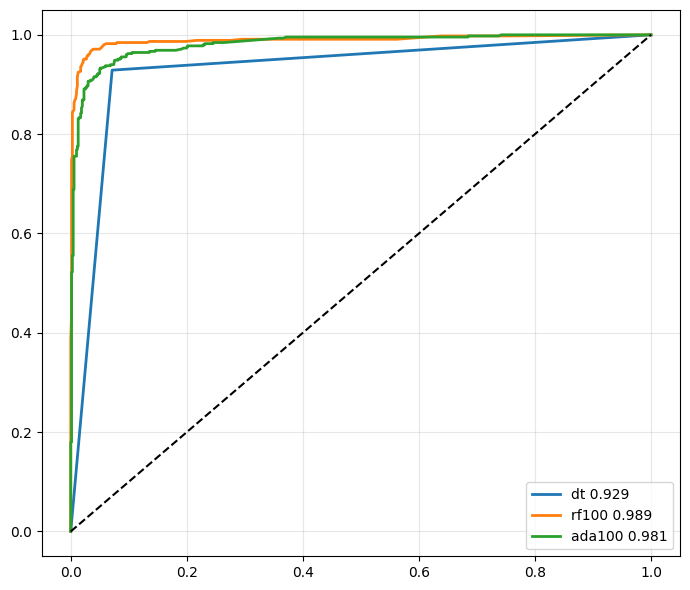

In [5]:
for n in [10, 50, 100, 500]:
    r(AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=n, random_state=1), "ada" + str(n))
t1 = DecisionTreeClassifier(criterion="entropy", random_state=1)
t1.fit(xtr, ytr)
f1 = RandomForestClassifier(n_estimators=100, random_state=1, n_jobs=-1)
f1.fit(xtr, ytr)
a1 = AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1), n_estimators=100, random_state=1)
a1.fit(xtr, ytr)
plt.figure(figsize=(7, 6))
for q, nm in [(t1, "dt"), (f1, "rf100"), (a1, "ada100")]:
    z = q.predict_proba(xte)[:, 1]
    fp, tp, _ = roc_curve(yte, z)
    plt.plot(fp, tp, lw=2, label=nm + " " + str(round(auc(fp, tp), 3)))
plt.plot([0, 1], [0, 1], "k--")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
col_names = ["class", "cap-shape", "cap-surface", "cap-color", "bruises", "odor", "gill-attachment", "gill-spacing", "gill-size", "gill-color", "stalk-shape", "stalk-root", "stalk-surface-above-ring", "stalk-surface-below-ring", "stalk-color-above-ring", "stalk-color-below-ring", "veil-type", "veil-color", "ring-number", "ring-type", "spore-print-color", "population", "habitat"]
mush_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/mushroom/agaricus-lepiota.data"
mush_df = pd.read_csv(mush_url, header=None, names=col_names)
X_m = mush_df.drop(columns=["class"])
y_m = mush_df["class"]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_m, y_m, test_size=0.25, random_state=1, stratify=y_m)
alpha = 1.0
classes = ["e", "p"]
n_train = len(y_train_m)
log_prior = {c: np.log((y_train_m == c).sum() / n_train) for c in classes}
class_count = {c: int((y_train_m == c).sum()) for c in classes}
features = list(X_train_m.columns)
log_cond = []
vocab_sizes = []
for col in features:
    vals = X_train_m[col].unique()
    vocab_sizes.append(len(vals))
    per_class = {}
    for c in classes:
        nc = class_count[c]
        per_class[c] = {}
        for v in vals:
            cnt = int(((y_train_m == c) & (X_train_m[col] == v)).sum())
            per_class[c][v] = np.log((cnt + alpha) / (nc + alpha * len(vals)))
    log_cond.append(per_class)
print((y_train_m == "e").sum() / n_train, (y_train_m == "p").sum() / n_train)
odor_idx = features.index("odor")
for c in classes:
    print(c, {v: round(np.exp(log_cond[odor_idx][c][v]), 4) for v in sorted(log_cond[odor_idx][c])})
n_test = len(X_test_m)
n_cls = len(classes)
log_scores = np.zeros((n_test, n_cls))
for row_i in range(n_test):
    for k, c in enumerate(classes):
        score = log_prior[c]
        for feat_i, col in enumerate(features):
            v = X_test_m.iloc[row_i][col]
            if v in log_cond[feat_i][c]:
                score += log_cond[feat_i][c][v]
            else:
                score += np.log(alpha / (class_count[c] + alpha * vocab_sizes[feat_i]))
        log_scores[row_i, k] = score
log_scores -= log_scores.max(axis=1, keepdims=True)
probs = np.exp(log_scores)
probs /= probs.sum(axis=1, keepdims=True)
print(probs[:5])
pred = np.array([classes[i] for i in np.argmax(log_scores, axis=1)])
print(accuracy_score(y_test_m, pred), precision_score(y_test_m, pred, pos_label="p"), recall_score(y_test_m, pred, pos_label="p"), f1_score(y_test_m, pred, pos_label="p"))
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
X_train_enc = enc.fit_transform(X_train_m)
X_test_enc = enc.transform(X_test_m)
y_train_poison = (y_train_m == "p").astype(int)
nb_sk = CategoricalNB(alpha=1.0)
nb_sk.fit(X_train_enc, y_train_poison)
pred_int = nb_sk.predict(X_test_enc)
pred = np.where(pred_int == 0, "e", "p")
print(accuracy_score(y_test_m, pred), precision_score(y_test_m, pred, pos_label="p"), recall_score(y_test_m, pred, pos_label="p"), f1_score(y_test_m, pred, pos_label="p"))


0.517971442639094 0.48202855736090594
e {'a': np.float64(0.0938), 'c': np.float64(0.0003), 'f': np.float64(0.0003), 'l': np.float64(0.0957), 'm': np.float64(0.0003), 'n': np.float64(0.8085), 'p': np.float64(0.0003), 's': np.float64(0.0003), 'y': np.float64(0.0003)}
p {'a': np.float64(0.0003), 'c': np.float64(0.0533), 'f': np.float64(0.5482), 'l': np.float64(0.0003), 'm': np.float64(0.0102), 'n': np.float64(0.0292), 'p': np.float64(0.0642), 's': np.float64(0.1463), 'y': np.float64(0.148)}
[[9.99999998e-01 1.65952480e-09]
 [4.53172119e-11 1.00000000e+00]
 [3.30482413e-15 1.00000000e+00]
 [6.99844491e-15 1.00000000e+00]
 [9.99994427e-01 5.57321932e-06]]
0.9561792220580995 0.9922566371681416 0.916241062308478 0.9527349973446628
0.9561792220580995 0.9922566371681416 0.916241062308478 0.9527349973446628
